### 0. Import librerie ed inizalizzazione

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import warnings
import random

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

np.random.seed(42)
random.seed(42)

warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.svm._base')

### 0.1 Import dataset

In [2]:
# Download della versione più recente del dataset
path = kagglehub.dataset_download("yasserh/breast-cancer-dataset")
print("Percorso dei file:", path)

# Caricamento del file CSV
df = pd.read_csv(path + "/breast-cancer.csv")

print("Dataset caricato con successo. Dimensioni:", df.shape)
df.head()

Percorso dei file: C:\Users\Michele\.cache\kagglehub\datasets\yasserh\breast-cancer-dataset\versions\1
Dataset caricato con successo. Dimensioni: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 0.2 Analisi preliminare dataset

In [3]:
# Dimensioni del dataset
print(f"Il dataset contiene {df.shape[0]} righe e {df.shape[1]} colonne.\n")

# Informazioni generali
df.info()

# Statistiche descrittive per le colonne numeriche
df.describe()

# Controllo dei valori mancanti
missing_values = df.isnull().sum()
print("Valori mancanti per colonna:\n", missing_values[missing_values > 0])

Il dataset contiene 569 righe e 32 colonne.

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float

### 0.3 Analisi target

diagnosis
B    357
M    212
Name: count, dtype: int64
Percentuali:
diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


C:\Users\Michele\AppData\Local\Temp\ipykernel_1384\2234296942.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis', palette='Set2')


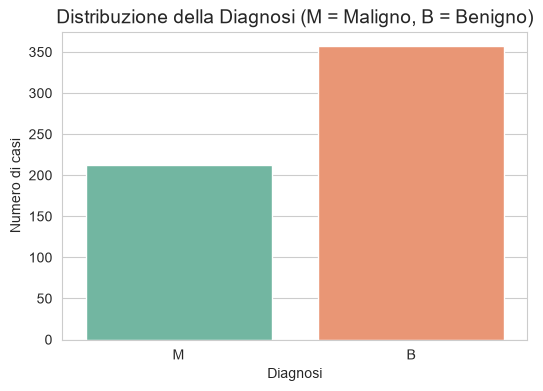

In [4]:
# Distribuzione della variabile target (valori originali: M e B)
print(df['diagnosis'].value_counts())
print(f"Percentuali:\n{df['diagnosis'].value_counts(normalize=True) * 100}")

# Countplot con le etichette originali
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Distribuzione della Diagnosi (M = Maligno, B = Benigno)', fontsize=14)
plt.xlabel('Diagnosi')
plt.ylabel('Numero di casi')
plt.show()

# Conversione della variabile target in numerica (M=1, B=0)
df['diagnosis'] = LabelEncoder().fit_transform(df['diagnosis'])

### 0.4 Analisi features

In [5]:
# Separazione diagnosi da features
features = df.drop(['id', 'diagnosis'], axis=1)
diagnosis = df['diagnosis']

# Informazioni generali
features.info()
diagnosis.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   radius_mean              569 non-null    float64
 1   texture_mean             569 non-null    float64
 2   perimeter_mean           569 non-null    float64
 3   area_mean                569 non-null    float64
 4   smoothness_mean          569 non-null    float64
 5   compactness_mean         569 non-null    float64
 6   concavity_mean           569 non-null    float64
 7   concave points_mean      569 non-null    float64
 8   symmetry_mean            569 non-null    float64
 9   fractal_dimension_mean   569 non-null    float64
 10  radius_se                569 non-null    float64
 11  texture_se               569 non-null    float64
 12  perimeter_se             569 non-null    float64
 13  area_se                  569 non-null    float64
 14  smoothness_se            569 non-null

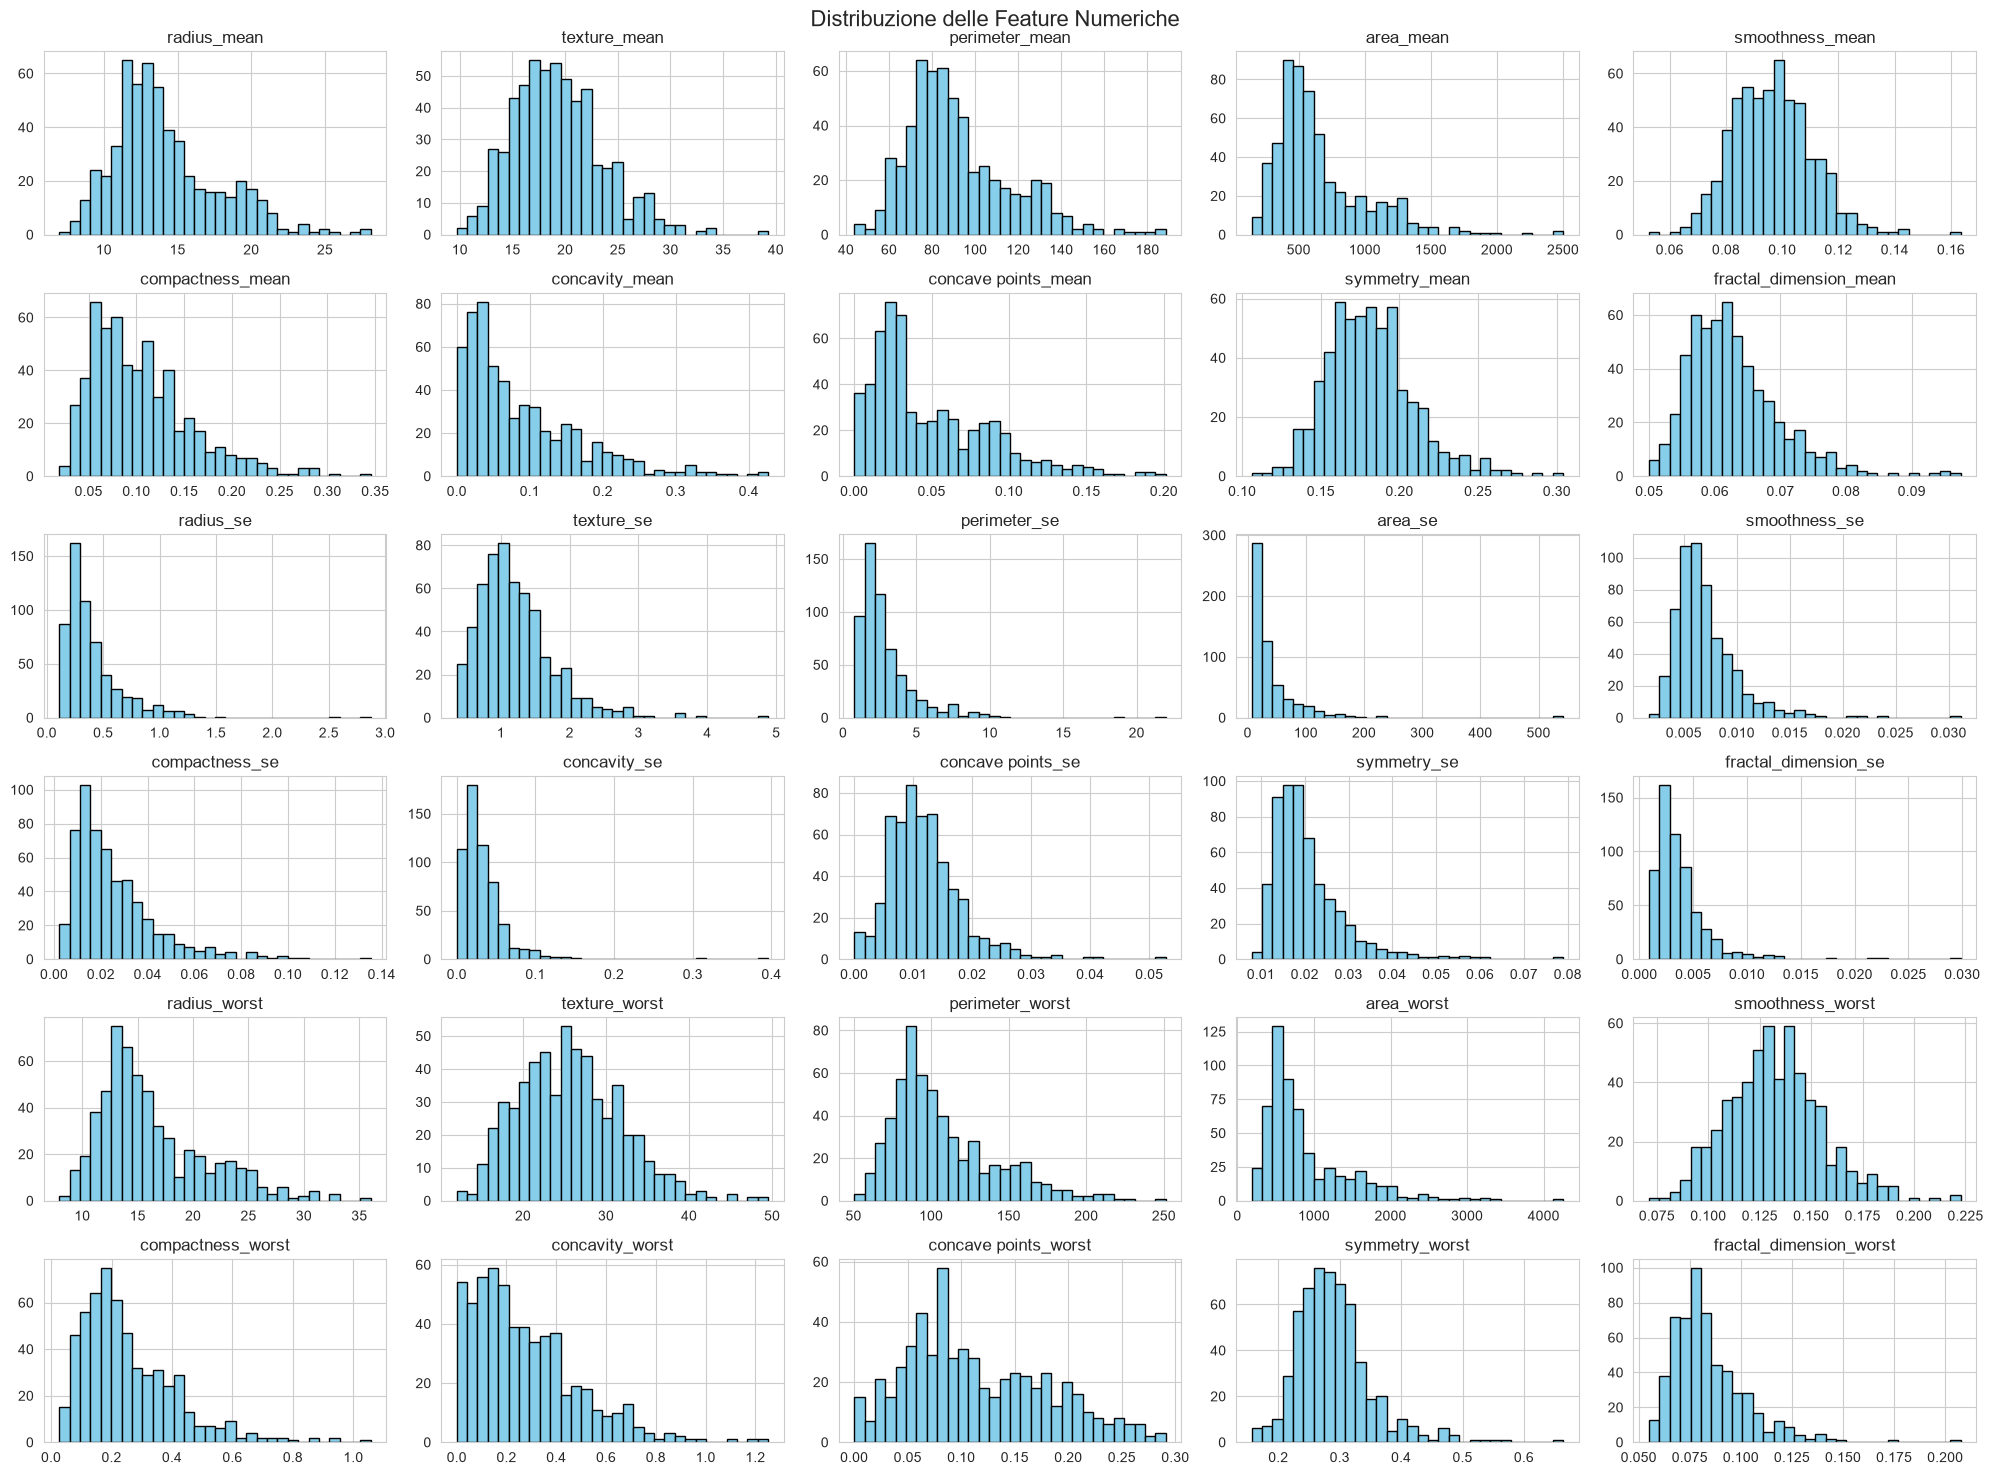

In [6]:
# Istogrammi per tutte le feature
features.hist(bins=30, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle('Distribuzione delle Feature Numeriche', fontsize=16)
plt.tight_layout()
plt.show()

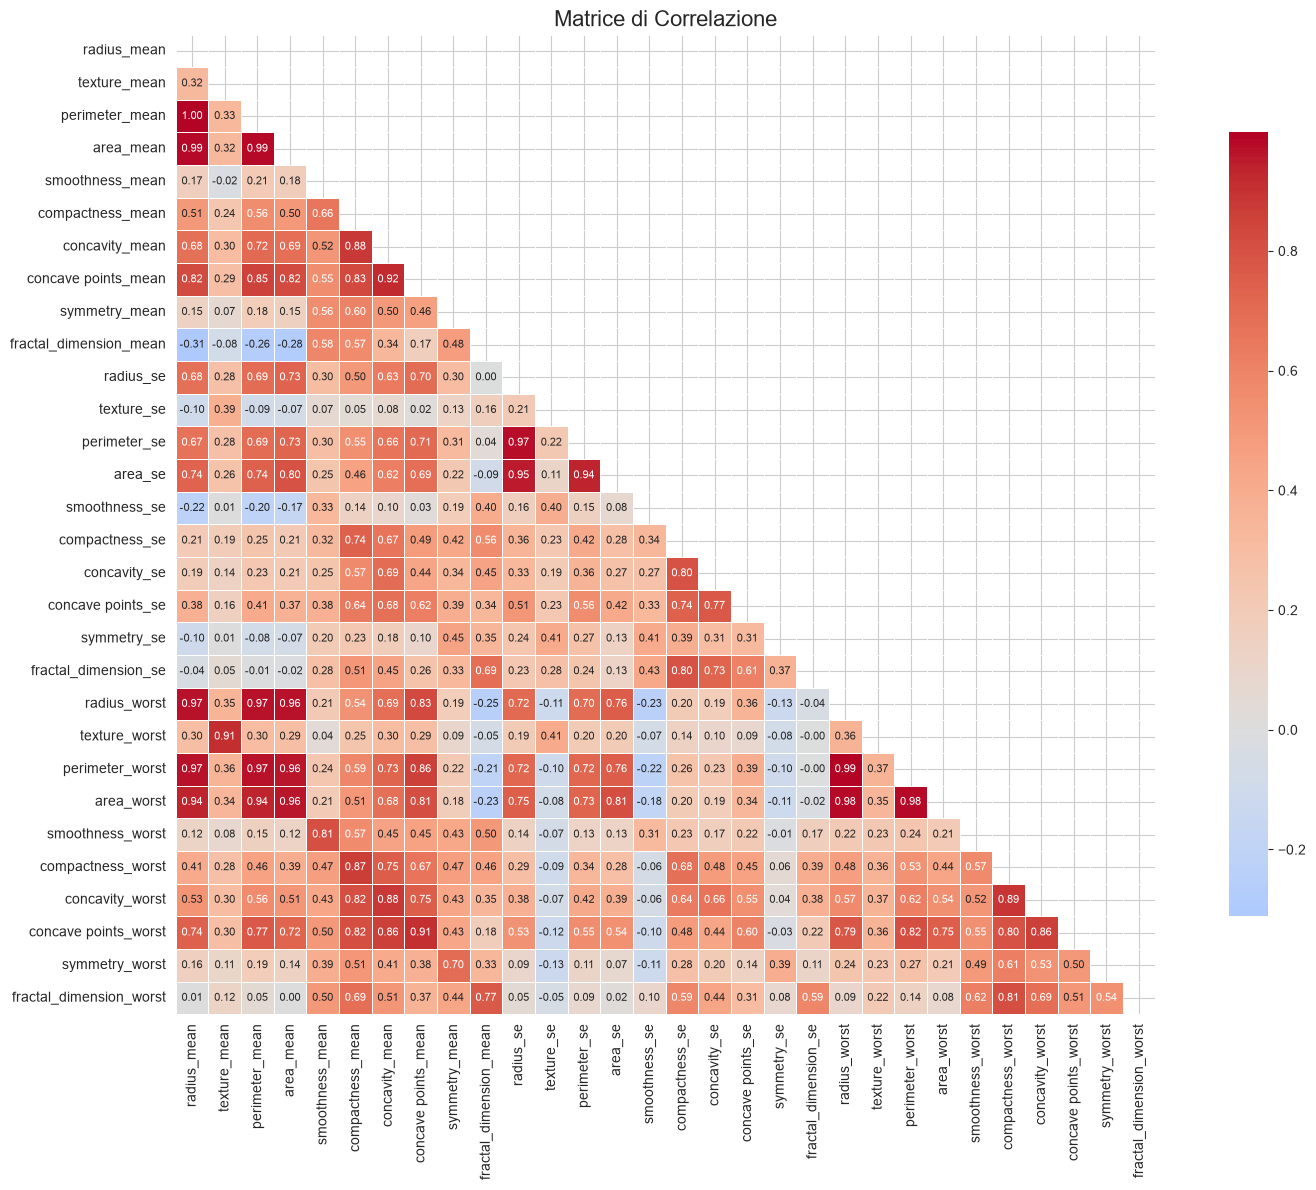

In [7]:
# Matrice di correlazione
plt.figure(figsize=(16, 12))
correlation_matrix = features.corr()

# Creazione di una maschera per il triangolo superiore e la diagonale
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Heatmap con maschera e annotazioni
sns.heatmap(correlation_matrix, 
            mask=mask,           # Nasconde triangolo superiore e diagonale
            annot=True,          # Mostra i valori numerici
            fmt='.2f',           # Formato con 2 decimali
            cmap='coolwarm',     
            center=0,            
            square=True,         
            linewidths=0.5,      
            cbar_kws={"shrink": 0.8},
            annot_kws={'size': 8})  # Dimensione del testo delle annotazioni

plt.title('Matrice di Correlazione', fontsize=16)
plt.tight_layout()
plt.show()

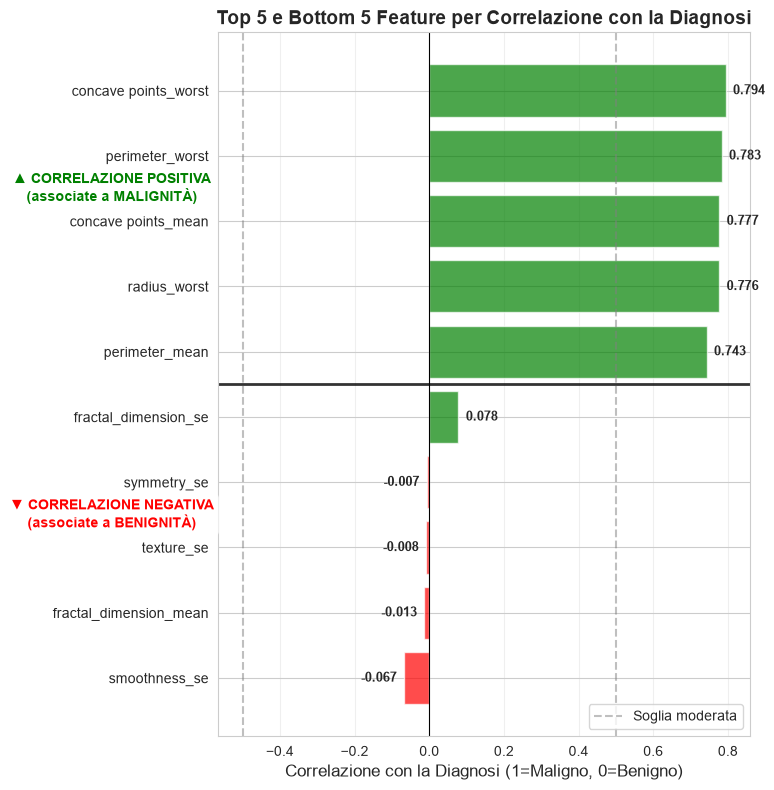

In [8]:
# Correlazione feature-target - Top 5 e Bottom 5
features_with_target = features.copy()
features_with_target['diagnosis'] = diagnosis

correlation_matrix_diag = features_with_target.corr()
corr_with_target = correlation_matrix_diag['diagnosis'].drop('diagnosis').sort_values(ascending=True)

# Selezionare top 5 (più positive) e bottom 5 (più negative)
top5 = corr_with_target.tail(5)  # Le 5 più positive
bottom5 = corr_with_target.head(5)  # Le 5 più negative

# Combinare e mantenere l'ordine (prima le negative, poi le positive)
selected_corr = pd.concat([bottom5, top5])

plt.figure(figsize=(8, 8))

# Colori: rosso per negativo, verde per positivo
colors = ['red' if x < 0 else 'green' for x in selected_corr.values]

# Barplot orizzontale
bars = plt.barh(selected_corr.index, selected_corr.values, color=colors, alpha=0.7)

# Aggiunta linea di separazione tra bottom5 e top5
# La linea viene posizionata tra il 5° e 6° elemento (indice 4.5 in termini di posizioni)
plt.axhline(y=4.5, color='black', linestyle='-', linewidth=2, alpha=0.8)

# Aggiunta etichette per identificare i due gruppi
plt.text(-0.85, 2.5, '▼ CORRELAZIONE NEGATIVA\n(associate a BENIGNITÀ)', 
         ha='center', va='center', fontsize=10, color='red', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
plt.text(-0.85, 7.5, '▲ CORRELAZIONE POSITIVA\n(associate a MALIGNITÀ)', 
         ha='center', va='center', fontsize=10, color='green', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.xlabel('Correlazione con la Diagnosi (1=Maligno, 0=Benigno)', fontsize=12)
plt.title('Top 5 e Bottom 5 Feature per Correlazione con la Diagnosi', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Soglia moderata')
plt.axvline(x=-0.5, color='gray', linestyle='--', alpha=0.5)
plt.grid(axis='x', alpha=0.3)

# Aggiunta dei valori sulle barre
for i, (bar, val) in enumerate(zip(bars, selected_corr.values)):
    # Posiziona il testo a destra per valori positivi, a sinistra per negativi
    if val > 0:
        plt.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')
    else:
        plt.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', ha='right', va='center', fontsize=9, fontweight='bold')

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 1. Preparazione dataset sporchi

In [9]:
X = features
y = diagnosis

# Dividi in train/test una volta per tutte (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 455, Test size: 114


### 1.1 Funzioni di sporcamento

In [10]:
def add_label_flipping(y, noise_ratio):
    """
    Flipping dei label: cambia il valore dei label selezionati casualmente
    """
    y_corrupted = y.copy()
    n_samples = len(y)
    n_flip = int(n_samples * noise_ratio)
    
    # Seleziona indici casuali da flipare
    flip_indices = np.random.choice(n_samples, n_flip, replace=False)
    
    # Flipping: 0->1, 1->0
    y_corrupted.iloc[flip_indices] = 1 - y_corrupted.iloc[flip_indices]
    
    return y_corrupted

def add_gaussian_noise(X, noise_ratio):
    """
    Aggiunge rumore gaussiano a una percentuale delle features
    """
    X_corrupted = X.copy()
    n_samples, n_features = X.shape
    n_noisy_features = int(n_features * noise_ratio)
    
    for col in np.random.choice(X.columns, n_noisy_features, replace=False):
        # Aggiunge rumore con deviazione standard = 0.1 * std della feature
        noise_std = 0.1 * X[col].std()
        noise = np.random.normal(0, noise_std, n_samples)
        X_corrupted[col] = X_corrupted[col] + noise
    
    return X_corrupted

def add_outliers(X, outlier_ratio):
    """
    Inietta outlier usando il metodo IQR: valori oltre 3*IQR dal Q3 o Q1
    """
    X_corrupted = X.copy()
    n_samples, n_features = X.shape
    n_outlier_samples = int(n_samples * outlier_ratio)
    
    for col in np.random.choice(X.columns, n_features, replace=False):
        # Seleziona righe casuali per questa feature
        outlier_rows = np.random.choice(n_samples, n_outlier_samples, replace=False)
        
        # Calcola IQR
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Genera outlier estremi (oltre 3*IQR)
        for row in outlier_rows:
            if np.random.random() > 0.5:
                # Outlier alto
                X_corrupted.loc[X_corrupted.index[row], col] = Q3 + 5 * IQR
            else:
                # Outlier basso
                X_corrupted.loc[X_corrupted.index[row], col] = Q1 - 5 * IQR
    
    return X_corrupted

def add_missing_features(X, missing_ratio):
    """
    Sostituisce valori con 0 (emulando NULL) per una percentuale delle celle
    """
    X_corrupted = X.copy()
    n_samples, n_features = X.shape
    n_missing = int(n_samples * n_features * missing_ratio)
    
    # Seleziona posizioni casuali da impostare a 0
    rows = np.random.choice(n_samples, n_missing, replace=True)
    cols = np.random.choice(n_features, n_missing, replace=True)
    
    for i in range(n_missing):
        col_name = X.columns[cols[i]]
        X_corrupted.iloc[rows[i], X_corrupted.columns.get_loc(col_name)] = 0
    
    return X_corrupted

def create_corrupted_dataset(X, y, corruption_type, corruption_ratio):
    """
    Crea una versione corrotta del dataset in base al tipo di corruzione
    """
    X_corr = X.copy()
    y_corr = y.copy()
    
    if corruption_type == 'label_flipping':
        y_corr = add_label_flipping(y, corruption_ratio)
    elif corruption_type == 'gaussian_noise':
        X_corr = add_gaussian_noise(X, corruption_ratio)
    elif corruption_type == 'outliers':
        X_corr = add_outliers(X, corruption_ratio)
    elif corruption_type == 'missing_features':
        X_corr = add_missing_features(X, corruption_ratio)
    
    return X_corr, y_corr

## 1.2 Creazione dataset

In [19]:
# Dataset pulito (nessuna corruzione)
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
y_train_clean = y_train.copy()
y_test_clean = y_test.copy()

print("Dataset pulito creato")
print(f"X_train shape: {X_train_clean.shape}")
print(f"y_train shape: {y_train_clean.shape}")

corruption_levels = [0.10, 0.20, 0.30, 0.40, 0.50]

# Label Flipped
label_flipping_datasets = {}

for level in corruption_levels:
    X_train_corr, y_train_corr = create_corrupted_dataset(
        X_train, y_train, 'label_flipping', level
    )
    
    label_flipping_datasets[level] = {
        'X_train': X_train_corr,
        'y_train': y_train_corr,
        'X_test': X_test_clean,
        'y_test': y_test_clean
    }
    
    # Verifica del flipping effettivo
    n_flipped = sum(y_train_corr != y_train)
    print(f"Label Flipping {int(level*100)}%: {n_flipped}/{len(y_train)} label cambiati ({n_flipped/len(y_train)*100:.1f}%)")

print("\nDataset con label flipping creati")

gaussian_noise_datasets = {}

for level in corruption_levels:
    X_train_corr, _ = create_corrupted_dataset(
        X_train, y_train, 'gaussian_noise', level
    )
    
    gaussian_noise_datasets[level] = {
        'X_train': X_train_corr,
        'y_train': y_train_clean,
        'X_test': X_test_clean,
        'y_test': y_test_clean
    }
    
    # Verifica del rumore aggiunto
    noise_magnitude = (X_train_corr - X_train).abs().mean().mean()
    print(f"Gaussian Noise {int(level*100)}%: Rumore medio aggiunto = {noise_magnitude:.4f}")

print("\nDataset con rumore gaussiano creati")

outlier_datasets = {}

for level in corruption_levels:
    X_train_corr, _ = create_corrupted_dataset(
        X_train, y_train, 'outliers', level
    )
    
    outlier_datasets[level] = {
        'X_train': X_train_corr,
        'y_train': y_train_clean,
        'X_test': X_test_clean,
        'y_test': y_test_clean
    }
    
    # Verifica outlier: conta valori > 3 std dalla media
    n_outliers = 0
    for col in X_train.columns:
        mean = X_train[col].mean()
        std = X_train[col].std()
        outliers = (X_train_corr[col] > mean + 3*std) | (X_train_corr[col] < mean - 3*std)
        n_outliers += outliers.sum()
    
    print(f"Outlier Injection {int(level*100)}%: {n_outliers} outlier totali nel training set")

print("\nDataset con outlier injection creati")

missing_features_datasets = {}

for level in corruption_levels:
    X_train_corr, _ = create_corrupted_dataset(
        X_train, y_train, 'missing_features', level
    )
    
    missing_features_datasets[level] = {
        'X_train': X_train_corr,
        'y_train': y_train_clean,
        'X_test': X_test_clean,
        'y_test': y_test_clean
    }
    
    # Verifica valori zero aggiunti
    n_zeros = (X_train_corr == 0).sum().sum()
    total_cells = X_train_corr.shape[0] * X_train_corr.shape[1]
    print(f"Missing Features {int(level*100)}%: {n_zeros}/{total_cells} celle a zero ({n_zeros/total_cells*100:.1f}%)")

print("\nDataset con missing features creati")

Dataset pulito creato
X_train shape: (455, 30)
y_train shape: (455,)
Label Flipping 10%: 45/455 label cambiati (9.9%)
Label Flipping 20%: 91/455 label cambiati (20.0%)
Label Flipping 30%: 136/455 label cambiati (29.9%)
Label Flipping 40%: 182/455 label cambiati (40.0%)
Label Flipping 50%: 227/455 label cambiati (49.9%)

Dataset con label flipping creati
Gaussian Noise 10%: Rumore medio aggiunto = 0.1069
Gaussian Noise 20%: Rumore medio aggiunto = 0.0025
Gaussian Noise 30%: Rumore medio aggiunto = 1.8272
Gaussian Noise 40%: Rumore medio aggiunto = 2.5026
Gaussian Noise 50%: Rumore medio aggiunto = 2.7249

Dataset con rumore gaussiano creati
Outlier Injection 10%: 1488 outlier totali nel training set
Outlier Injection 20%: 2826 outlier totali nel training set
Outlier Injection 30%: 4136 outlier totali nel training set
Outlier Injection 40%: 5459 outlier totali nel training set
Outlier Injection 50%: 6783 outlier totali nel training set

Dataset con outlier injection creati
Missing Featur

In [20]:
def standardize_dataset(X_train, X_test):
    """
    Standardizza i dati usando la media e std del training set
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Riporta in DataFrame
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
    
    return X_train_scaled, X_test_scaled, scaler

# Standardizza tutti i dataset
all_corrupted_datasets = {
    'clean': {
        'X_train': X_train_clean,
        'X_test': X_test_clean,
        'y_train': y_train_clean,
        'y_test': y_test_clean
    },
    'label_flipping': label_flipping_datasets,
    'gaussian_noise': gaussian_noise_datasets,
    'outliers': outlier_datasets,
    'missing_features': missing_features_datasets
}

# Applica standardizzazione
standardized_datasets = {}

# Dataset pulito
X_train_s, X_test_s, _ = standardize_dataset(X_train_clean, X_test_clean)
standardized_datasets['clean'] = {
    'X_train': X_train_s,
    'X_test': X_test_s,
    'y_train': y_train_clean,
    'y_test': y_test_clean
}

# Dataset corrotti
for corr_type in ['label_flipping', 'gaussian_noise', 'outliers', 'missing_features']:
    standardized_datasets[corr_type] = {}
    for level, data in all_corrupted_datasets[corr_type].items():
        X_train_s, X_test_s, _ = standardize_dataset(data['X_train'], data['X_test'])
        standardized_datasets[corr_type][level] = {
            'X_train': X_train_s,
            'X_test': X_test_s,
            'y_train': data['y_train'],
            'y_test': data['y_test']
        }

print("Tutti i dataset standardizzati")

Tutti i dataset standardizzati


# 2. Addestramento SVM

In [21]:
results = {
    'dataset_type': [],
    'corruption_level': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

def evaluate_svm(X_train, y_train, X_test, y_test, dataset_name, corruption_level=0):
    """
    Addestra SVM e restituisce metriche
    """
    # Addestra SVM con kernel lineare (ottimo per questo dataset)
    svm = SVC(kernel='linear', random_state=42, C=1.0)
    svm.fit(X_train, y_train)
    
    # Predizioni
    y_pred = svm.predict(X_test)
    
    # Metriche
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary')
    rec = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    
    # Salva risultati
    results['dataset_type'].append(dataset_name)
    results['corruption_level'].append(corruption_level)
    results['accuracy'].append(acc)
    results['precision'].append(prec)
    results['recall'].append(rec)
    results['f1_score'].append(f1)
    
    print(f"{dataset_name} (corruption={corruption_level}): Acc={acc:.4f}, F1={f1:.4f}")
    
    return svm, y_pred

In [25]:
clean_data = standardized_datasets['clean']
svm_clean, pred_clean = evaluate_svm(
    clean_data['X_train'], clean_data['y_train'],
    clean_data['X_test'], clean_data['y_test'],
    'clean', 0
)

for level in corruption_levels:
    data = standardized_datasets['label_flipping'][level]
    svm_lf, _ = evaluate_svm(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'label_flipping', level
    )

for level in corruption_levels:
    data = standardized_datasets['gaussian_noise'][level]
    svm_gn, _ = evaluate_svm(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'gaussian_noise', level
    )

for level in corruption_levels:
    data = standardized_datasets['outliers'][level]
    svm_out, _ = evaluate_svm(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'outliers', level
    )

for level in corruption_levels:
    data = standardized_datasets['missing_features'][level]
    svm_mf, _ = evaluate_svm(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'missing_features', level
    )

clean (corruption=0): Acc=0.9649, F1=0.9500
label_flipping (corruption=0.1): Acc=0.9474, F1=0.9250
label_flipping (corruption=0.2): Acc=0.9649, F1=0.9500
label_flipping (corruption=0.3): Acc=0.8947, F1=0.8378
label_flipping (corruption=0.4): Acc=0.8860, F1=0.8354
label_flipping (corruption=0.5): Acc=0.3860, F1=0.2857
gaussian_noise (corruption=0.1): Acc=0.9561, F1=0.9383
gaussian_noise (corruption=0.2): Acc=0.9649, F1=0.9500
gaussian_noise (corruption=0.3): Acc=0.9561, F1=0.9367
gaussian_noise (corruption=0.4): Acc=0.9561, F1=0.9383
gaussian_noise (corruption=0.5): Acc=0.9561, F1=0.9367
outliers (corruption=0.1): Acc=0.9123, F1=0.8649
outliers (corruption=0.2): Acc=0.8772, F1=0.8000
outliers (corruption=0.3): Acc=0.9035, F1=0.8493
outliers (corruption=0.4): Acc=0.7982, F1=0.6230
outliers (corruption=0.5): Acc=0.7632, F1=0.5263
missing_features (corruption=0.1): Acc=0.9561, F1=0.9438
missing_features (corruption=0.2): Acc=0.9035, F1=0.8842
missing_features (corruption=0.3): Acc=0.8333, 

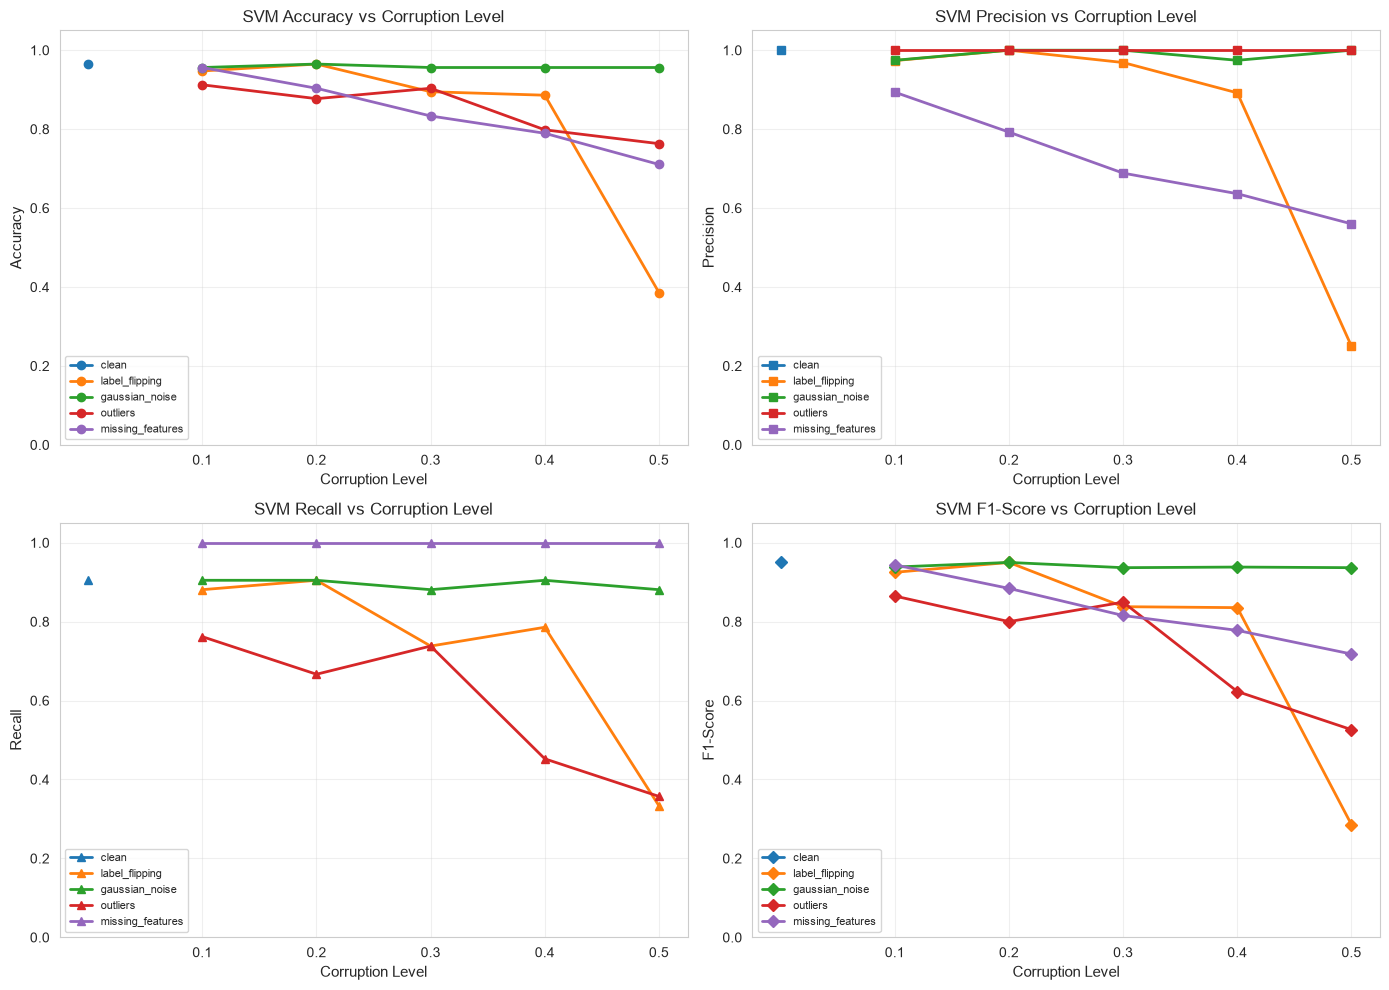

In [ ]:
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
markers = ['o', 's', '^', 'D']

for idx, (metric, title, marker) in enumerate(zip(metrics, titles, markers)):
    ax = axes[idx // 2, idx % 2]
    
    for dataset in results_df['dataset_type'].unique():
        subset = results_df[results_df['dataset_type'] == dataset]
        ax.plot(subset['corruption_level'], subset[metric], marker=marker, label=dataset, linewidth=2, markersize=6)
    
    ax.set_xlabel('Corruption Level', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'SVM {title} vs Corruption Level', fontsize=12)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(corruption_levels)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## 3. Random Forest

In [26]:
results = {
    'dataset_type': [],
    'corruption_level': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

def evaluate_random_forest(X_train, y_train, X_test, y_test, dataset_name, corruption_level=0):
    """
    Addestra Random Forest e restituisce metriche
    """
    # Addestra Random Forest con 100 alberi (default)
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    
    # Predizioni
    y_pred = rf.predict(X_test)
    
    # Metriche
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary')
    rec = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    
    # Salva risultati
    results['dataset_type'].append(dataset_name)
    results['corruption_level'].append(corruption_level)
    results['accuracy'].append(acc)
    results['precision'].append(prec)
    results['recall'].append(rec)
    results['f1_score'].append(f1)
    
    print(f"{dataset_name} (corruption={corruption_level}): Acc={acc:.4f}, F1={f1:.4f}")
    
    return rf, y_pred

In [27]:
# Clean dataset
clean_data = standardized_datasets['clean']
rf_clean, pred_clean = evaluate_random_forest(
    clean_data['X_train'], clean_data['y_train'],
    clean_data['X_test'], clean_data['y_test'],
    'clean', 0
)

# Label flipping
for level in corruption_levels:
    data = standardized_datasets['label_flipping'][level]
    rf_lf, _ = evaluate_random_forest(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'label_flipping', level
    )

# Gaussian noise
for level in corruption_levels:
    data = standardized_datasets['gaussian_noise'][level]
    rf_gn, _ = evaluate_random_forest(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'gaussian_noise', level
    )

# Outliers
for level in corruption_levels:
    data = standardized_datasets['outliers'][level]
    rf_out, _ = evaluate_random_forest(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'outliers', level
    )

# Missing features
for level in corruption_levels:
    data = standardized_datasets['missing_features'][level]
    rf_mf, _ = evaluate_random_forest(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'missing_features', level
    )

clean (corruption=0): Acc=0.9737, F1=0.9630
label_flipping (corruption=0.1): Acc=0.9737, F1=0.9630
label_flipping (corruption=0.2): Acc=0.9737, F1=0.9639
label_flipping (corruption=0.3): Acc=0.8947, F1=0.8500
label_flipping (corruption=0.4): Acc=0.7281, F1=0.6353
label_flipping (corruption=0.5): Acc=0.4474, F1=0.3762
gaussian_noise (corruption=0.1): Acc=0.9649, F1=0.9500
gaussian_noise (corruption=0.2): Acc=0.9649, F1=0.9512
gaussian_noise (corruption=0.3): Acc=0.9649, F1=0.9500
gaussian_noise (corruption=0.4): Acc=0.9737, F1=0.9630
gaussian_noise (corruption=0.5): Acc=0.9561, F1=0.9367
outliers (corruption=0.1): Acc=0.9474, F1=0.9250
outliers (corruption=0.2): Acc=0.9474, F1=0.9231
outliers (corruption=0.3): Acc=0.9561, F1=0.9383
outliers (corruption=0.4): Acc=0.9474, F1=0.9250
outliers (corruption=0.5): Acc=0.9649, F1=0.9512
missing_features (corruption=0.1): Acc=0.9474, F1=0.9268
missing_features (corruption=0.2): Acc=0.9561, F1=0.9398
missing_features (corruption=0.3): Acc=0.9561, 

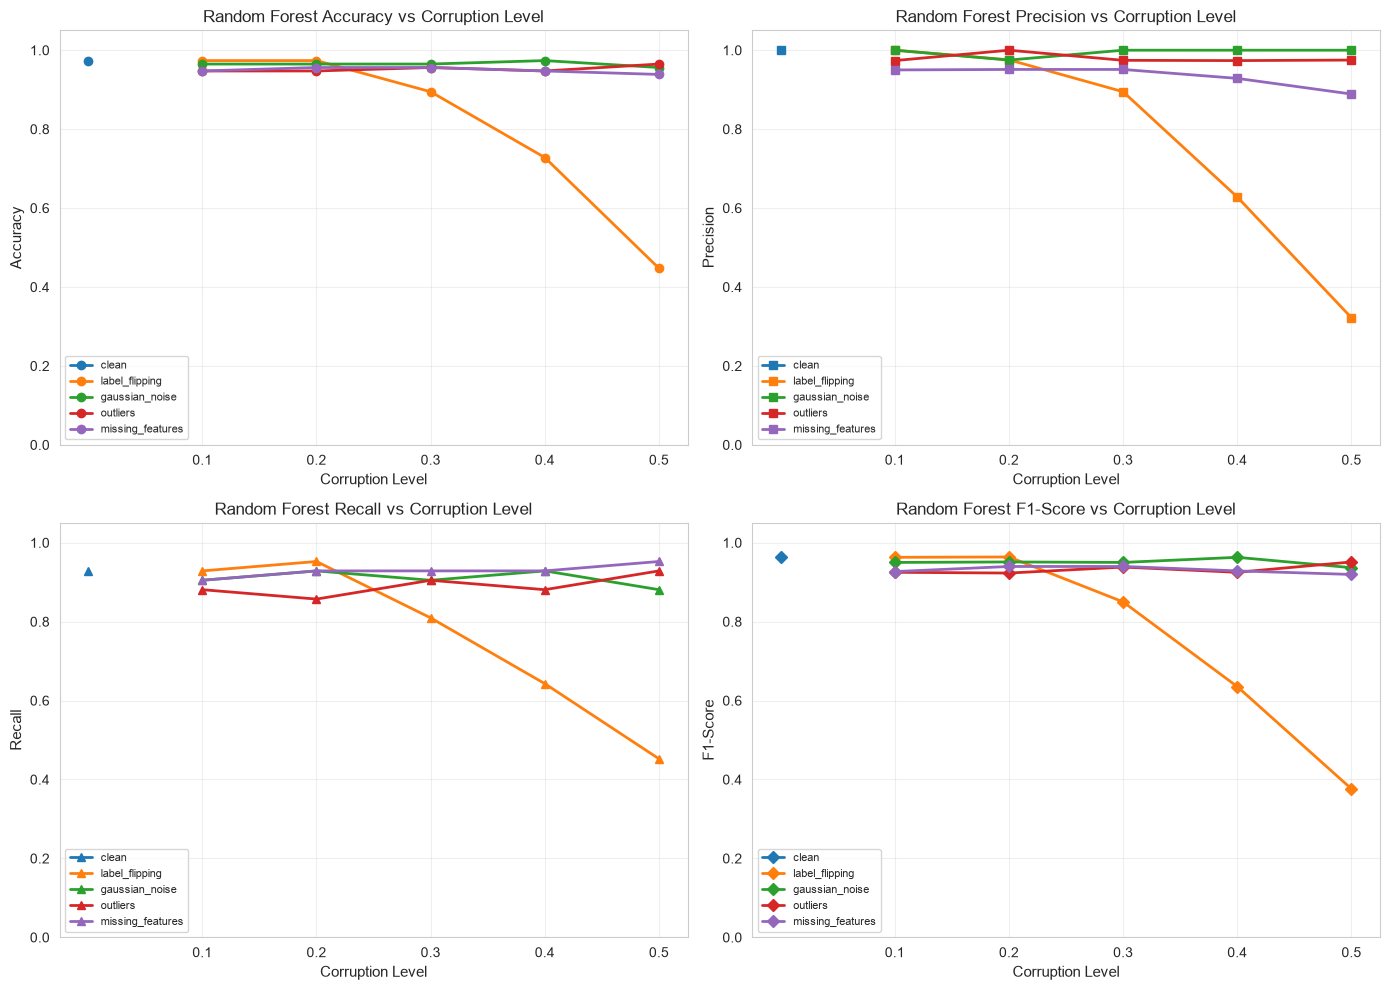

In [28]:
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
markers = ['o', 's', '^', 'D']

for idx, (metric, title, marker) in enumerate(zip(metrics, titles, markers)):
    ax = axes[idx // 2, idx % 2]
    
    for dataset in results_df['dataset_type'].unique():
        subset = results_df[results_df['dataset_type'] == dataset]
        ax.plot(subset['corruption_level'], subset[metric], marker=marker, label=dataset, linewidth=2, markersize=6)
    
    ax.set_xlabel('Corruption Level', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'Random Forest {title} vs Corruption Level', fontsize=12)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(corruption_levels)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

## Rete Neurale

In [36]:
results = {
    'dataset_type': [],
    'corruption_level': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1_score': []
}

def evaluate_mlp(X_train, y_train, X_test, y_test, dataset_name, corruption_level=0):
    """
    Addestra una MLP con architettura semplice + early stopping.
    """
    mlp = MLPClassifier(
        hidden_layer_sizes=(64, 32),   # due layer nascosti
        activation='relu',
        alpha=0.0001,                  # regolarizzazione L2 (weight decay)
        early_stopping=True,           # ferma se validation loss non migliora
        validation_fraction=0.1,
        random_state=42,
        max_iter=200
    )
    mlp.fit(X_train, y_train)
    
    y_pred = mlp.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', zero_division=0)
    rec = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
    
    results['dataset_type'].append(dataset_name)
    results['corruption_level'].append(corruption_level)
    results['accuracy'].append(acc)
    results['precision'].append(prec)
    results['recall'].append(rec)
    results['f1_score'].append(f1)
    
    print(f"{dataset_name} (corruption={corruption_level}): Acc={acc:.4f}, F1={f1:.4f}")
    
    return mlp, y_pred

In [37]:
# Clean dataset
clean_data = standardized_datasets['clean']
rf_clean, pred_clean = evaluate_mlp(
    clean_data['X_train'], clean_data['y_train'],
    clean_data['X_test'], clean_data['y_test'],
    'clean', 0
)

# Label flipping
for level in corruption_levels:
    data = standardized_datasets['label_flipping'][level]
    rf_lf, _ = evaluate_mlp(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'label_flipping', level
    )

# Gaussian noise
for level in corruption_levels:
    data = standardized_datasets['gaussian_noise'][level]
    rf_gn, _ = evaluate_mlp(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'gaussian_noise', level
    )

# Outliers
for level in corruption_levels:
    data = standardized_datasets['outliers'][level]
    rf_out, _ = evaluate_mlp(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'outliers', level
    )

# Missing features
for level in corruption_levels:
    data = standardized_datasets['missing_features'][level]
    rf_mf, _ = evaluate_mlp(
        data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        'missing_features', level
    )

clean (corruption=0): Acc=0.8596, F1=0.7714
label_flipping (corruption=0.1): Acc=0.9211, F1=0.8831
label_flipping (corruption=0.2): Acc=0.9649, F1=0.9500
label_flipping (corruption=0.3): Acc=0.8158, F1=0.6957
label_flipping (corruption=0.4): Acc=0.7632, F1=0.6667
label_flipping (corruption=0.5): Acc=0.5263, F1=0.3415
gaussian_noise (corruption=0.1): Acc=0.8596, F1=0.7714
gaussian_noise (corruption=0.2): Acc=0.8596, F1=0.7714
gaussian_noise (corruption=0.3): Acc=0.8596, F1=0.7714
gaussian_noise (corruption=0.4): Acc=0.8596, F1=0.7714
gaussian_noise (corruption=0.5): Acc=0.8772, F1=0.8056
outliers (corruption=0.1): Acc=0.8860, F1=0.8169
outliers (corruption=0.2): Acc=0.7719, F1=0.5517
outliers (corruption=0.3): Acc=0.6754, F1=0.2128
outliers (corruption=0.4): Acc=0.6316, F1=0.0000
outliers (corruption=0.5): Acc=0.6316, F1=0.0000
missing_features (corruption=0.1): Acc=0.9035, F1=0.8571
missing_features (corruption=0.2): Acc=0.9123, F1=0.8750
missing_features (corruption=0.3): Acc=0.9123, 

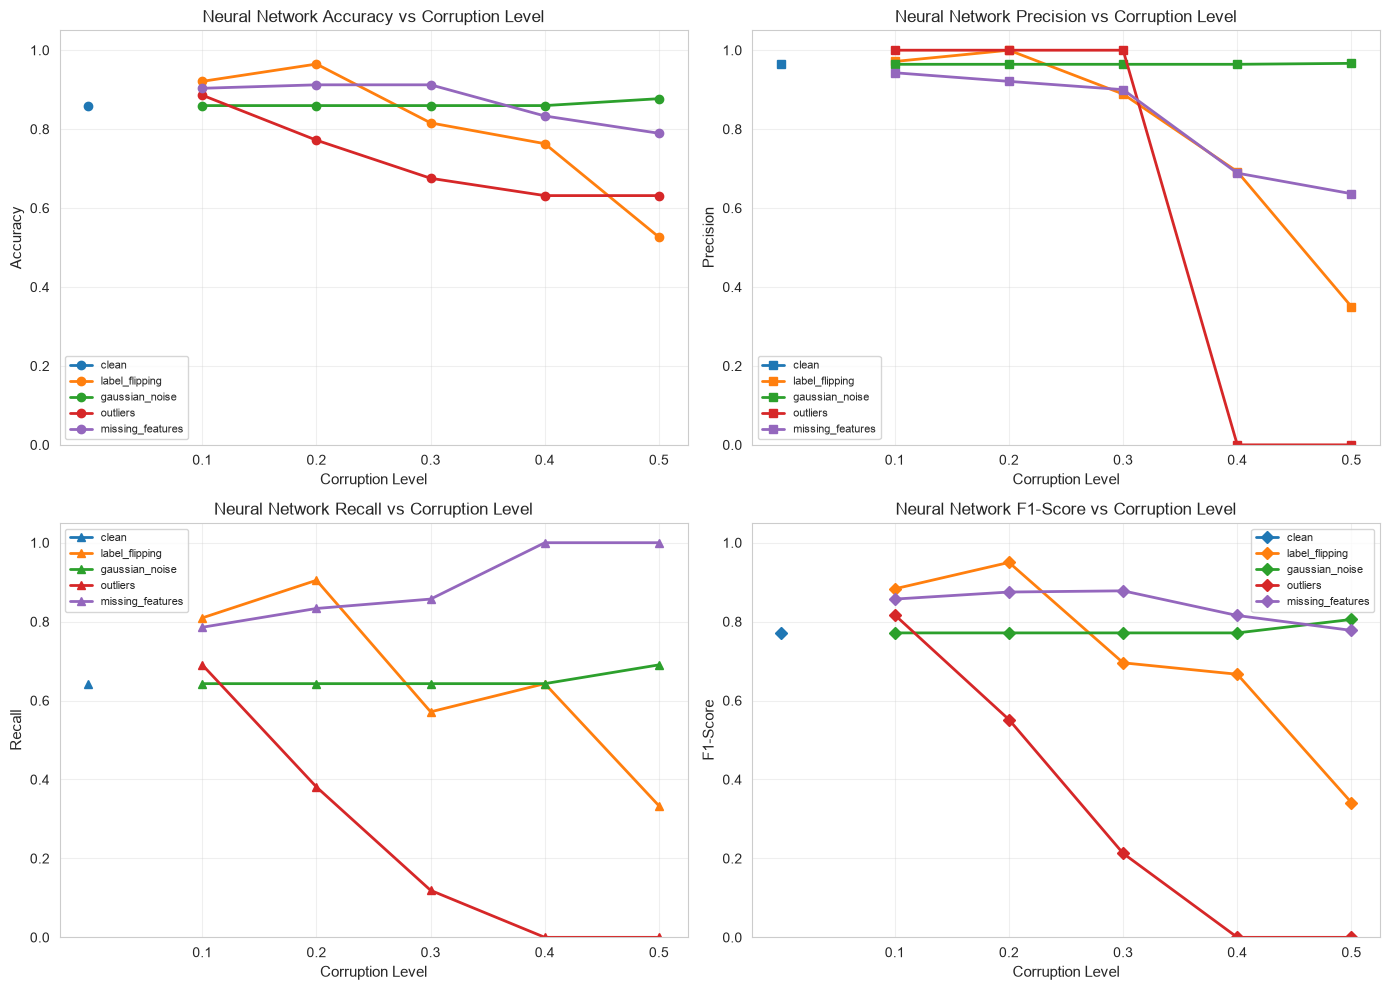

In [38]:
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
markers = ['o', 's', '^', 'D']

for idx, (metric, title, marker) in enumerate(zip(metrics, titles, markers)):
    ax = axes[idx // 2, idx % 2]
    
    for dataset in results_df['dataset_type'].unique():
        subset = results_df[results_df['dataset_type'] == dataset]
        ax.plot(subset['corruption_level'], subset[metric], marker=marker, label=dataset, linewidth=2, markersize=6)
    
    ax.set_xlabel('Corruption Level', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'Neural Network {title} vs Corruption Level', fontsize=12)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(corruption_levels)
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()